This notebook is used to get the Experiment results for the dropclass-publication

# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

from catboost import CatBoostClassifier

from sklearn.preprocessing import PolynomialFeatures

In [2]:
# import new main notebook
df_main = pd.read_excel('../data/df_main_edited.xlsx')
display(df_main.head())
df_main.info()

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat,breaking_up_receding,splashing_semi,rebound_total,rebound_true,jet_ejection
0,3,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
1,4,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
2,5,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
3,7,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0
4,8,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   one_drop                         372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   breaking_up                      372 non-null    int64  
 4   net_impact                       372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   voltage                          372 non-null    float64
 7   long_impulse_duration            372 non-null    int64  
 8   height                           372 non-null    float64
 9   inclination                      372 non-null    int64  
 10  droplet_diameter                 372 non-null    float64
 11  liquid_density                   372 non-null    int64  
 12  surface_tension       

Let us remind **new classes definition**:
- **breaking_up_receding**. Include only tests with *'Number of detached small droplets during **Receding or Rim merging**' > 0*
- **splashing_semi**. Include only tests with *a few count of 'Number of detached small droplets during Spreading' [1,5]*
- **rebound_total**. Include only tests with label *'Rebound' == 2*, so only total rebound of thw whole droplet
- **rebound_true**. Include all **real** rebound cases - partial and total rebound: *('Rebound' == 2) OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound'>0)*
- **jet_ejection**. Include jet ejection tests without rebound: *('Rim merging or Central jet ejecting'==2)AND NOT[('Number of detached droplets during Rebound'>0) OR ('Rebound'==2)]*

## Add particle density (in kg/m^3)

In [3]:
df_main['particle_density'] = df_main['liquid_density'] * df_main['particle_liquid_density_ratio']
df_main['particle_density'] = df_main['particle_density'].round(0)
df_main['particle_density'].value_counts()

particle_density
1000.0    183
1200.0    147
450.0      23
2200.0     19
Name: count, dtype: int64

## Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$We\_Re = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

## Labels combination
Let us create "combined"-columns for splashing and jet ejection-rebound
- combine *splashing* and *splashing_semi* 
- combine *jet_ejection* and *rebound_true*

In [4]:
def get_splashing_combined(row):
    if row['splashing'] == 1:
        return 2
    if row['splashing_semi'] == 1:
        return 1
    return 0

df_main['splashing_combined'] = df_main.apply(get_splashing_combined, axis=1)
df_main['splashing_combined'].value_counts()

splashing_combined
2    174
0    153
1     45
Name: count, dtype: int64

In [5]:
def get_rebound_combined(row):
    if row['rebound_true'] == 1:
        return 2
    if row['jet_ejection'] == 1:
        return 1
    return 0

df_main['rebound_combined'] = df_main.apply(get_rebound_combined, axis=1)
df_main['rebound_combined'].value_counts()

rebound_combined
0    273
1     55
2     44
Name: count, dtype: int64

## Drop unnecessary columns and rename others

In [6]:
# Drop unused columns
drop_columns = ['one_drop', 'splashing', 'splashing_semi', 'breaking_up', 'rebound', 'rebound_total', 'rebound_true', 'jet_ejection', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary', 'height', 'particle_diameter_cat']
df = df_main.drop(drop_columns, axis=1)

# Rename columns
rename_columns = {
    'splashing_combined': 'splashing',
    'breaking_up_receding': 'breaking_up',
    'rebound_combined': 'rebound',
}

df = df.rename(rename_columns, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   inclination                      372 non-null    int64  
 3   droplet_diameter                 372 non-null    float64
 4   liquid_density                   372 non-null    int64  
 5   surface_tension                  372 non-null    float64
 6   viscosity                        372 non-null    float64
 7   particle_mean_diameter           372 non-null    float64
 8   particle_liquid_density_ratio    372 non-null    float64
 9   volume_fraction                  372 non-null    float64
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  roughness_binary      

## Reorder columns

16 columns: 'test', [labels] - 4, [features_original] - 11

7 columns: aggregated

In [7]:
labels = ['net_impact', 'splashing', 'breaking_up', 'rebound']
# do not forget 'test'
features_original = ['wettability', 'roughness', 'liquid_density', 'surface_tension', 'viscosity', 'particle_mean_diameter', 'particle_density', 'volume_fraction', 'droplet_diameter', 'velocity', 'inclination']

features_aggregated = ['roughness_binary', 'particle_liquid_density_ratio', 'volume_fraction_binary', 'particle_droplet_diameter_ratio', 'Re', 'We', 'We_Re']

columns_sorted = ['test'] + features_original + features_aggregated + labels
len(columns_sorted)

23

In [8]:
df = df[columns_sorted]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   wettability                      372 non-null    object 
 2   roughness                        372 non-null    float64
 3   liquid_density                   372 non-null    int64  
 4   surface_tension                  372 non-null    float64
 5   viscosity                        372 non-null    float64
 6   particle_mean_diameter           372 non-null    float64
 7   particle_density                 372 non-null    float64
 8   volume_fraction                  372 non-null    float64
 9   droplet_diameter                 372 non-null    float64
 10  velocity                         372 non-null    float64
 11  inclination                      372 non-null    int64  
 12  roughness_binary      

## Check volume fraction

In [9]:
df_main[df_main['volume_fraction']>=0.08].shape[0] == df_main[df_main['volume_fraction_binary']==1].shape[0]

True

In [10]:
df_main[df_main['volume_fraction']<=0.05].shape[0] == df_main[df_main['volume_fraction_binary']==0].shape[0]

True

## Prepare text definitions of the features

In [11]:
def get_splashing_type(value):
    if value == 0:
        return 'no splashing'
    if value == 1:
        return 'semi splashing'
    else:
        return 'splashing'

df['splashing_type'] = df['splashing'].apply(get_splashing_type)
df['splashing_type'].value_counts()

splashing_type
splashing         174
no splashing      153
semi splashing     45
Name: count, dtype: int64

In [12]:
def get_volume_fraction_binary_type(value):
    if value == 1:
        return '0.08 .. 0.10'
    else:
        return '0.04 .. 0.05'

df['volume_fraction_binary_type'] = df['volume_fraction_binary'].apply(get_volume_fraction_binary_type)
df['volume_fraction_binary_type'].value_counts()

volume_fraction_binary_type
0.08 .. 0.10    271
0.04 .. 0.05    101
Name: count, dtype: int64

In [13]:
def get_rebound_type(value):
    if value == 1:
        return 'jet ejection'
    if value == 2:
        return 'rebound'
    else:
        return 'no'

df['rebound_type'] = df['rebound'].apply(get_rebound_type)
df['rebound_type'].value_counts()

rebound_type
no              273
jet ejection     55
rebound          44
Name: count, dtype: int64

In [14]:
def get_breaking_up_type(value):
    if value == 1:
        return 'yes'
    else:
        return 'no'

df['breaking_up_type'] = df['breaking_up'].apply(get_breaking_up_type)
df['breaking_up_type'].value_counts()

breaking_up_type
no     312
yes     60
Name: count, dtype: int64

# Research

## Splashing

Let us plot different scatter-plots with Re_We at the bottom

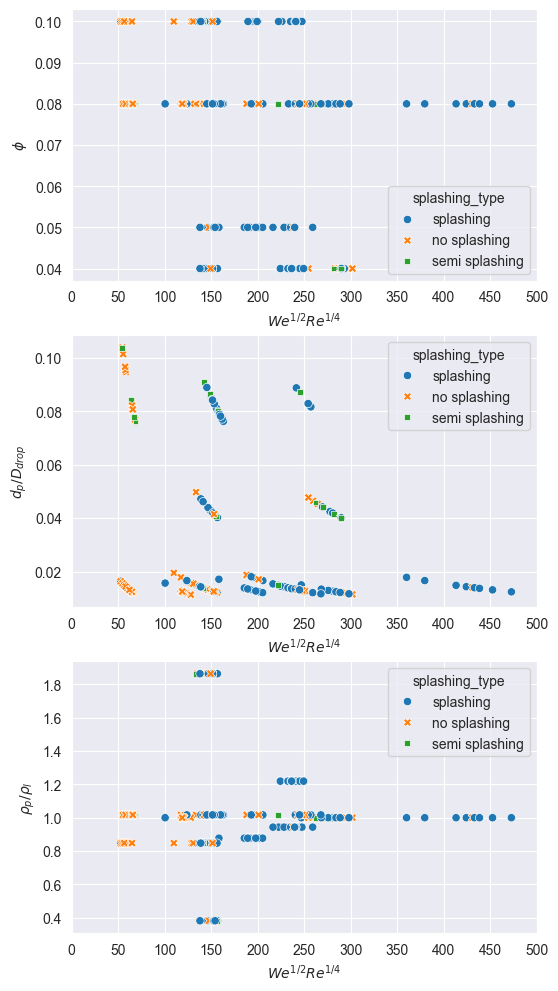

In [15]:
fig, (ax_volume_fraction, ax_diam_ratio, ax_density_ratio) = plt.subplots(3, 1, figsize=(6,12))
sns.scatterplot(data=df, x='We_Re', y='volume_fraction', hue='splashing_type', style='splashing_type', ax=ax_volume_fraction)
sns.scatterplot(data=df, x='We_Re', y='particle_droplet_diameter_ratio', hue='splashing_type', style='splashing_type', ax=ax_diam_ratio)
sns.scatterplot(data=df, x='We_Re', y='particle_liquid_density_ratio', hue='splashing_type', style='splashing_type', ax=ax_density_ratio)

axes = (ax_volume_fraction, ax_diam_ratio, ax_density_ratio)

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction.set_ylabel('$\phi$')
ax_diam_ratio.set_ylabel('$d_p/D_{drop}$')
ax_density_ratio.set_ylabel('$\\rho_{p}/\\rho_{l}$');

**Note:** volume_fraction plot is incorrect, since values 0.04 and 0.08 same as 0.05 and 0.10 respectively.

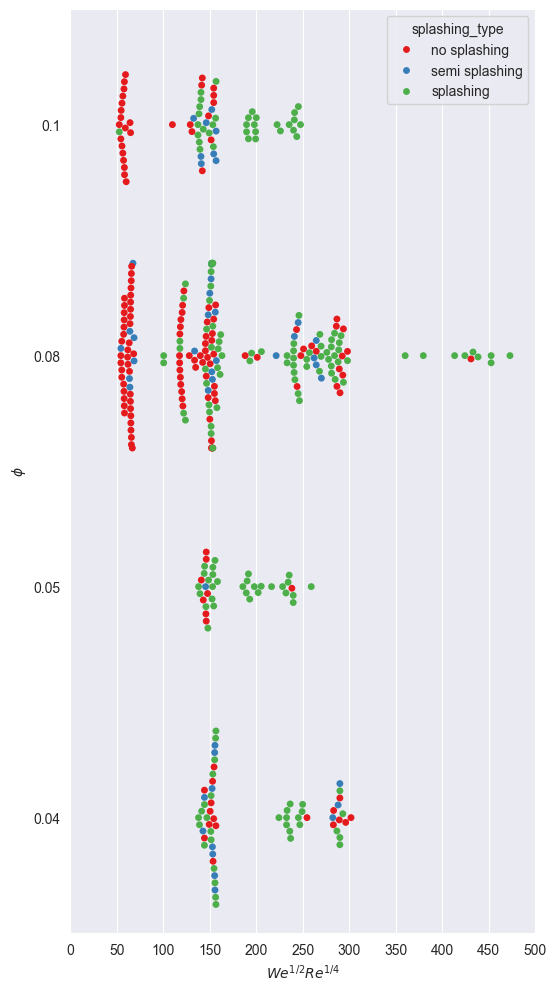

In [16]:
sns.color_palette('Set2')

fig, ax_volume_fraction_swarm = plt.subplots(figsize=(6,12))
sns.swarmplot(data=df, x='We_Re', y='volume_fraction', hue='splashing_type', # style='splashing_type', 
              ax=ax_volume_fraction_swarm, orient='h', size=4.95, order=[0.1, 0.08, 0.05, 0.04],
              hue_order=['no splashing', 'semi splashing', 'splashing'],
              palette='Set1'
            )


axes = (ax_volume_fraction_swarm, )

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction_swarm.set_ylabel('$\phi$');

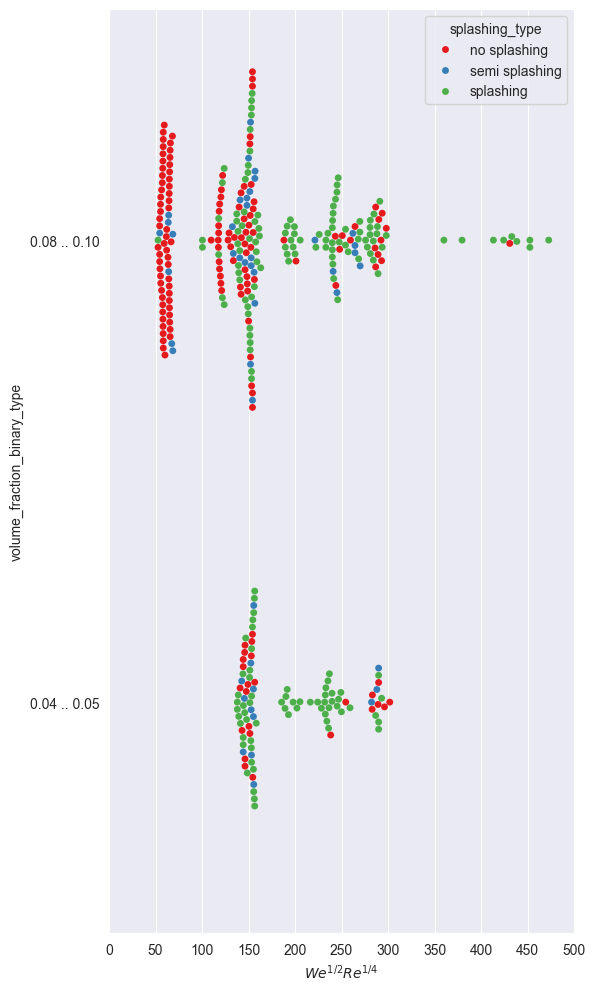

In [17]:
sns.color_palette('Set2')

fig, ax_volume_fraction_binary_swarm = plt.subplots(figsize=(6,12))
sns.swarmplot(data=df, x='We_Re', y='volume_fraction_binary_type', hue='splashing_type', # style='splashing_type', 
              ax=ax_volume_fraction_binary_swarm, orient='h', size=4.95, order=['0.08 .. 0.10', '0.04 .. 0.05'],
              hue_order=['no splashing', 'semi splashing', 'splashing'],
              palette='Set1'
            )


axes = (ax_volume_fraction_binary_swarm, )

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction_swarm.set_ylabel('$\phi$');

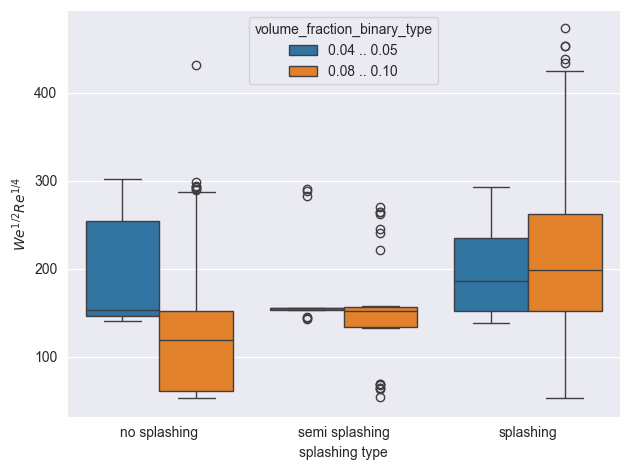

In [18]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='splashing_type', y='We_Re', 
    order=['no splashing', 'semi splashing', 'splashing'], 
    hue='volume_fraction_binary_type',
    hue_order=['0.04 .. 0.05', '0.08 .. 0.10'],
    # flierprops={"marker": "x"},
    ax=ax
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('splashing type');
fig.tight_layout()

Difficult to interpret this plot

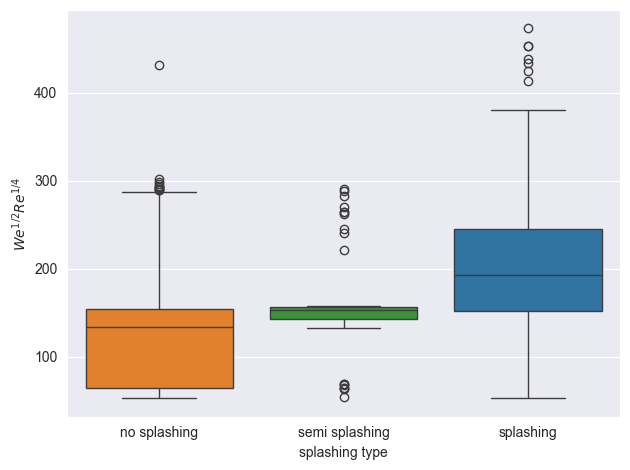

In [19]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='splashing_type', y='We_Re', 
    order=['no splashing', 'semi splashing', 'splashing'], 
    hue='splashing_type',
    # flierprops={"marker": "x"},
    ax=ax
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('splashing type');
fig.tight_layout()

### Check outliers


In [20]:

def get_outliers(series:pd.Series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    median = series.median()
    
    IQR = Q3 - Q1
    
    outliers_tuple = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    
    return outliers_tuple

We_Re_high_outlier = get_outliers(df[df['splashing'] == 0]['We_Re'])[1]
print(f'We_Re high outlier boundary: {We_Re_high_outlier:.2f}')
df[(df['splashing'] == 0) & (df['We_Re'] >= We_Re_high_outlier)]

We_Re high outlier boundary: 287.43


,test,wettability,roughness,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_density,volume_fraction,droplet_diameter,...,We,We_Re,net_impact,splashing,breaking_up,rebound,splashing_type,volume_fraction_binary_type,rebound_type,breaking_up_type
73,94,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.04,0.003530,...,756.666109,296.205123,1,0,0,0,no splashing,0.04 .. 0.05,no,no
74,95,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.04,0.003620,...,775.957880,301.851240,1,0,0,0,no splashing,0.04 .. 0.05,no,no
97,120,neutral,0.04,1000,0.0732,0.00104,0.000138,1000.0,0.04,0.003420,...,733.087279,289.255160,1,0,0,0,no splashing,0.04 .. 0.05,no,no
98,121,neutral,0.04,1000,0.0732,0.00104,0.000138,1000.0,0.04,0.003430,...,735.230809,289.889260,1,0,0,0,no splashing,0.04 .. 0.05,no,no
175,198,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003490,...,748.091989,293.684216,1,0,0,0,no splashing,0.08 .. 0.10,no,no
244,267,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003470,...,743.804929,292.421057,1,0,0,0,no splashing,0.08 .. 0.10,no,no
246,269,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003420,...,733.087279,289.255160,1,0,0,0,no splashing,0.08 .. 0.10,no,no
264,288,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003560,...,763.096699,298.091117,1,0,0,0,no splashing,0.08 .. 0.10,no,no
267,291,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003480,...,745.948459,293.052863,1,0,0,0,no splashing,0.08 .. 0.10,no,no
269,293,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003432,...,735.766691,290.047713,1,0,0,0,no splashing,0.08 .. 0.10,no,no


Check these tests

Tests 94, 95, 198. They gave someking of pseudo-net impact: no detaching droplets, but spot includes some droplet "branches":

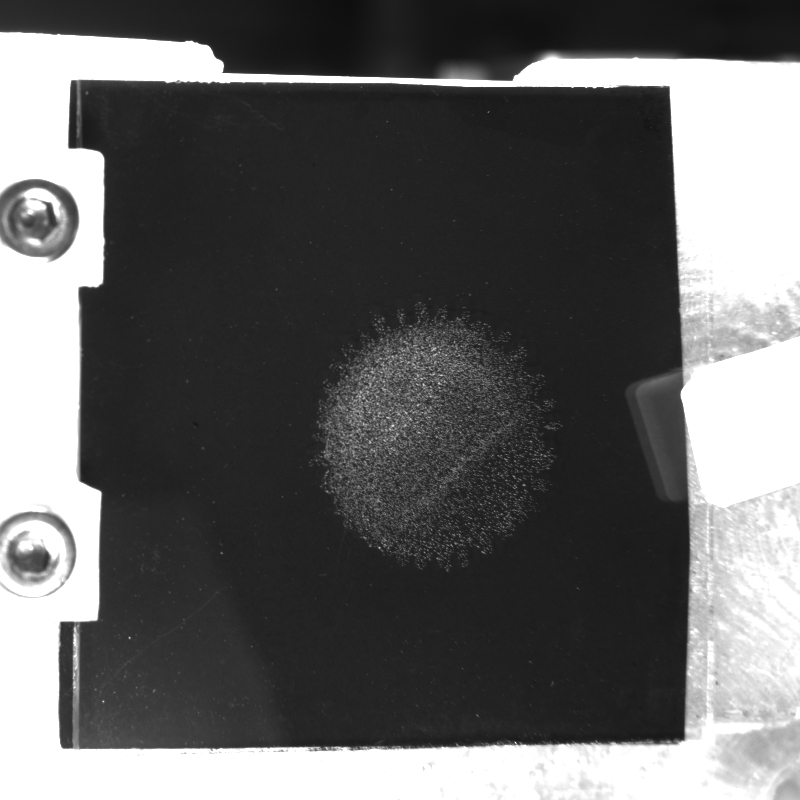

120, 365 - splashing cases!

121 - looks like splashing: tiny droplets + detaching during receding

267, 269, 288, 291, 293 - pseudo-net impact (like 94, but with inclination):

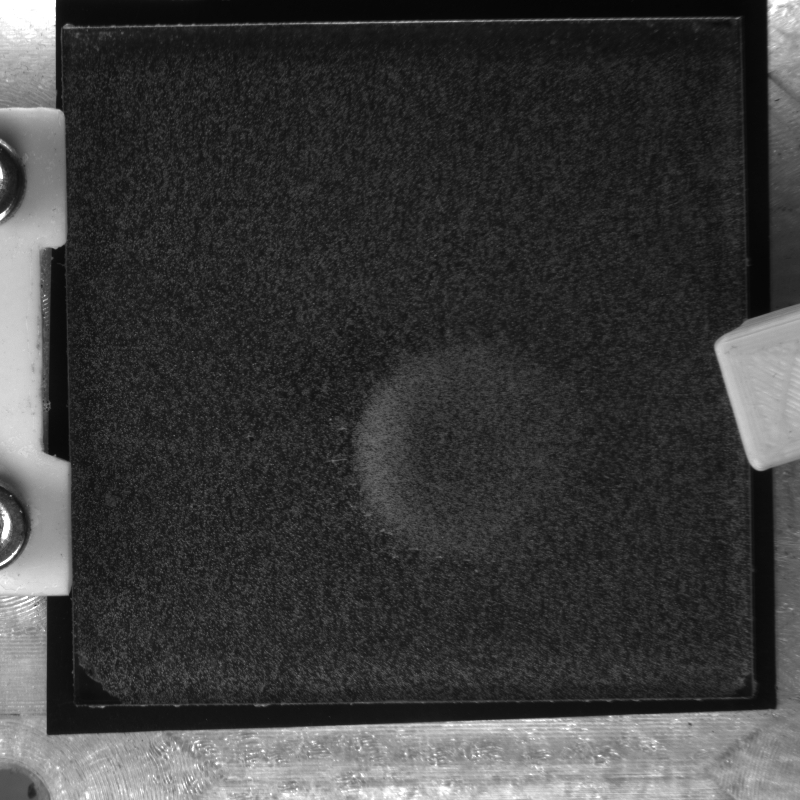

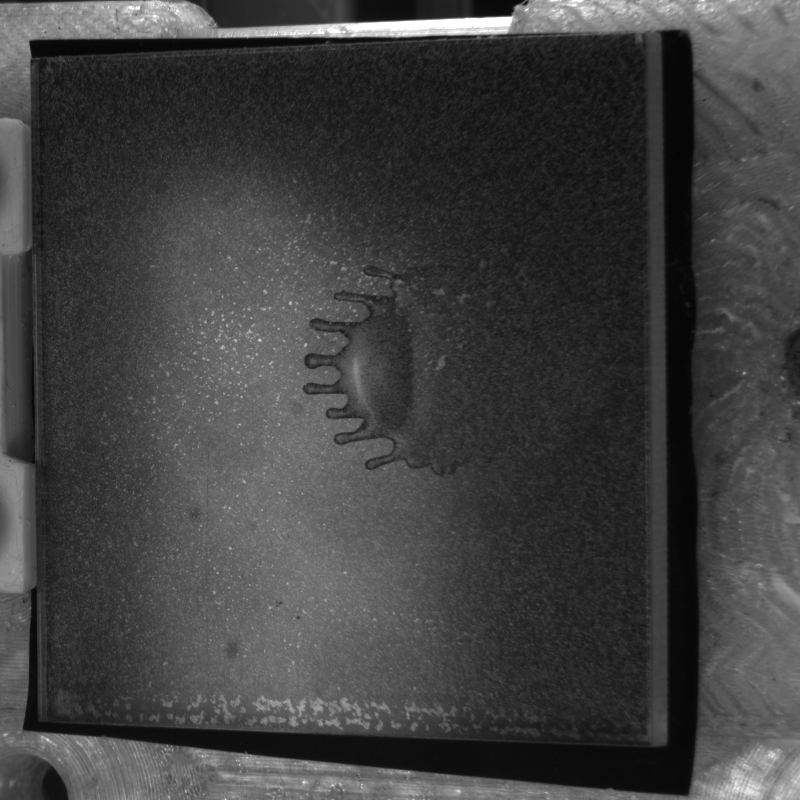

So, we can consider this cases as **semi-splashing (or even splashing)**

## Rebound

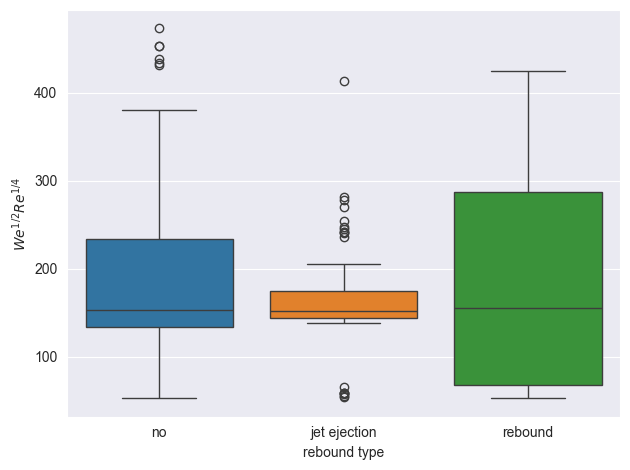

In [21]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='rebound_type', y='We_Re',
    order=['no', 'jet ejection', 'rebound'],
    hue='rebound_type',
    ax=ax,
)

ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('rebound type');
fig.tight_layout()

No sufficient difference

## Breaking up

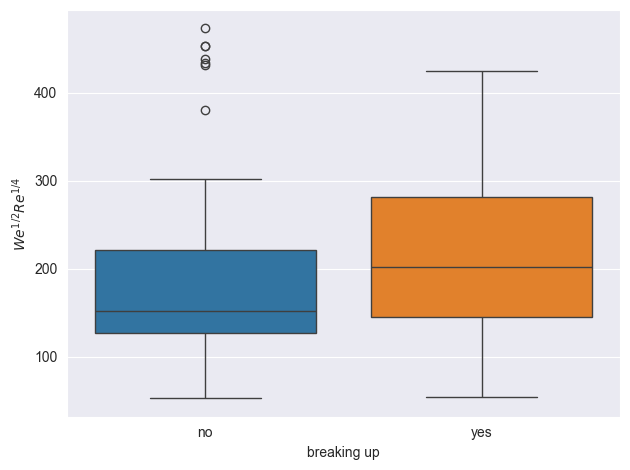

In [22]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='breaking_up_type', y='We_Re', 
    hue='breaking_up_type',
    ax=ax,
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('breaking up');
fig.tight_layout()

Let us consider duplicates. Do they have the same labels?

# ML-models predictions

TODO: plot ML-models contours

- **particle_droplet_diameter_ratio** = particle_mean_diameter / droplet_diameter
- **particle_liquid_density_ratio** = particle_density / liquid_density
- ~~volume_fraction~~

in dependence on the **We_Re**

In [23]:
df[['We_Re', 'particle_droplet_diameter_ratio', 'particle_liquid_density_ratio', 'volume_fraction']].describe().T

,count,mean,std,min,25%,50%,75%,max
We_Re,372.0,171.483225,81.819240,52.684981,133.397611,152.920577,236.153834,472.780129
particle_droplet_diameter_ratio,372.0,0.026760,0.025510,0.011339,0.012604,0.013540,0.024635,0.103774
particle_liquid_density_ratio,372.0,0.994035,0.261595,0.381356,0.943396,1.000000,1.016949,1.864407
volume_fraction,372.0,0.073952,0.020020,0.040000,0.050000,0.080000,0.080000,0.100000


## Load ML-models

### Net impact

In [24]:
net_impact_model = CatBoostClassifier()
net_impact_model.load_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_alternative_1')

In [25]:
net_impact_model.feature_names_

['inclination',
 'surface_tension',
 'viscosity',
 'particle_mean_diameter',
 'particle_liquid_density_ratio',
 'wettability',
 'roughness_binary',
 'volume_fraction_binary',
 'Re',
 'We']

In [26]:
data = pd.DataFrame(
    {
        'inclination': [0],
        'surface_tension': [0.0732],
        'viscosity': [0.00104],
        'particle_mean_diameter': [0.0001375],
        'particle_liquid_density_ratio': [1],
        'wettability': ['lyophilic'],
        'roughness_binary': [0],
        'volume_fraction_binary': [1],
        'Re': [11559.6766277027],
        'We': [650.561371584699],
    }
)

In [27]:
net_impact_model.predict_proba(data)[:,1] # Probability of net impact

array([0.39291602])

### Splashing

In [28]:
splashing_model = CatBoostClassifier()
splashing_model.load_model('../utils_functionality/models/models_pickles/tuned_models/splashing_pf_1')

In [29]:
splashing_model.feature_names_

['inclination',
 'surface_tension',
 'viscosity',
 'particle_mean_diameter',
 'particle_liquid_density_ratio',
 'wettability',
 'roughness',
 'Re',
 'We',
 'Re_1/4',
 'We_1/4',
 'Re_1/4^2',
 'Re_1/4 We_1/4',
 'We_1/4^2']

Prepare dataframe

In [30]:
data_splash = pd.DataFrame(
    {
        'inclination': [0],
        'surface_tension': [0.0732],
        'viscosity': [0.00104],
        'particle_mean_diameter': [0.0001375],
        'particle_liquid_density_ratio': [1],
        'wettability': ['lyophilic'],
        'roughness': [0.04],
        'Re': [11559.6766277027],
        'We': [650.561371584699],
    }
)


def get_poly_df(source_df):
    
    # To be sure, that source_df does not change
    df = source_df.copy()
    
    df['Re_1/4'] = df['Re']**(1/4)
    df['We_1/4'] = df['We']**(1/4)

    pf = PolynomialFeatures(include_bias=False)
    pf.fit(df[['Re_1/4', 'We_1/4']])

    pf_only = pd.DataFrame(
        pf.transform(df[['Re_1/4', 'We_1/4']]),
        columns = pf.get_feature_names_out()
    )

    df = pd.concat([df, pf_only.iloc[:, 2:]], axis=1)
    return df


data_pf = get_poly_df(data_splash)
data_pf

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
0,0,0.0732,0.00104,0.000138,1,lyophilic,0.04,11559.676628,650.561372,10.368989,5.050357,107.515937,52.367096,25.506105


In [31]:
splashing_model.predict_proba(data_pf)[:,1]

array([0.12077243])

Model performance tested.

## Prepare datasets for plots

Let us set horisontal lyophillic smooth substrate (inclination = 0; wettability = 'lyophillic', roughness = 0.1).

Also, let us consider water-glycerol solution (liquid_density = 1180; viscosity = 0.0231; surface_tension = 0.0679),
and droplets with some median diameter (droplet_diameter = 0.00318).

Let us consider 8-10% suspension concentration (volume_fraction_binary = 1).

We will vary both (in two plots) **particle_mean_diameter** (in range 0.0000415...0.000275) and **particle_liquid_density_ratio** (in range 0.38 .. 1.86) - for y-axis.

Also we will vary droplet **velocity** in range (1.98 .. 5.94) to get different We_Re values for x-axis.

Let us consider the statistics of the selected experiments:

In [32]:
wet_mask = df['wettability'] == 'lyophilic'
roughness_mask = df['roughness'] == 0.1
inclination_mask = df['inclination'] == 0
density_mask = df['liquid_density'] == 1180

glycerol_df = df[wet_mask & roughness_mask & inclination_mask & density_mask]
display(glycerol_df.describe().T)
display(glycerol_df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
test,43.0,183.465116,9.041606e+01,50.000000,113.500000,172.000000,236.000000,360.000000
roughness,43.0,0.100000,2.808406e-17,0.100000,0.100000,0.100000,0.100000,0.100000
liquid_density,43.0,1180.000000,0.000000e+00,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000
surface_tension,43.0,0.067900,1.404203e-17,0.067900,0.067900,0.067900,0.067900,0.067900
viscosity,43.0,0.023100,0.000000e+00,0.023100,0.023100,0.023100,0.023100,0.023100
particle_mean_diameter,43.0,0.000109,9.801003e-05,0.000041,0.000041,0.000041,0.000138,0.000275
particle_density,43.0,1160.465116,4.239213e+02,450.000000,1000.000000,1200.000000,1200.000000,2200.000000
volume_fraction,43.0,0.069535,2.192558e-02,0.040000,0.045000,0.080000,0.080000,0.100000
droplet_diameter,43.0,0.003142,2.318781e-04,0.002500,0.003025,0.003180,0.003315,0.003560
velocity,43.0,3.961141,1.058660e+00,1.980571,3.961141,3.961141,3.961141,5.941712


,count,unique,top,freq
wettability,43,1,lyophilic,43
splashing_type,43,3,no splashing,26
volume_fraction_binary_type,43,2,0.08 .. 0.10,27
rebound_type,43,1,no,43
breaking_up_type,43,1,no,43


In [33]:
def create_mesh_df(**params_for_mesh):
    # Get meshed values
    value_list = list(params_for_mesh.values())
    values = np.meshgrid(*value_list)
    # Get array of values
    stacked_array = np.hstack([value.reshape(-1, 1) for value in values])

    df = pd.DataFrame(
        stacked_array,
        columns = params_for_mesh.keys()
    )
    return df


vel_dens_df = create_mesh_df(
    # velocity=np.linspace(1.98, 5.94, 50),
    # particle_liquid_density_ratio=np.linspace(0.38, 1.86, 50)
    velocity=np.linspace(0.0, 7.0, 50),
    particle_liquid_density_ratio=np.linspace(0.3, 1.9, 50)
)
print('vel_dens_df')
display(vel_dens_df)

vel_diam_df = create_mesh_df(
    # velocity=np.linspace(1.98, 5.94, 50),
    # particle_mean_diameter=np.linspace(0.0000415, 0.000275, 50)
    velocity=np.linspace(0.0, 7.0, 50),
    particle_mean_diameter=np.linspace(20e-6, 350e-6, 50)
)
print('vel_diam_df')
display(vel_diam_df)

vel_dens_df


,velocity,particle_liquid_density_ratio
0,0.000000,0.3
1,0.142857,0.3
2,0.285714,0.3
3,0.428571,0.3
4,0.571429,0.3
...,...,...
2495,6.428571,1.9
2496,6.571429,1.9
2497,6.714286,1.9
2498,6.857143,1.9


vel_diam_df


,velocity,particle_mean_diameter
0,0.000000,0.00002
1,0.142857,0.00002
2,0.285714,0.00002
3,0.428571,0.00002
4,0.571429,0.00002
...,...,...
2495,6.428571,0.00035
2496,6.571429,0.00035
2497,6.714286,0.00035
2498,6.857143,0.00035


In [34]:
const_params_list_dens = [
    'wettability', 
    'roughness',
    'inclination',
    'liquid_density',
    'viscosity',
    'surface_tension',
    'droplet_diameter',
    'volume_fraction_binary',
    
    'particle_mean_diameter',
]

const_params_list_diam = [
    'wettability', 
    'roughness',
    'inclination',
    'liquid_density',
    'viscosity',
    'surface_tension',
    'droplet_diameter',
    'volume_fraction_binary',
    
    'particle_liquid_density_ratio',
]


def get_top_object_value(series:pd.Series):
    return series.value_counts().sort_values(ascending=False).index[0]


def get_const_params(
    df:pd.DataFrame,
    columns:list,
):
    params_dict = {}
    
    for column in columns:
        series = df[column]
        # For object - get frequent value
        if series.dtype == 'O':
            params_dict[column] = get_top_object_value(series)
        # For other types
        else:
            value = series.median()
            if series.dtype == 'int64':
                value = int(value)
            params_dict[column] = value
            
    
    return params_dict


def create_dataframe(
    const_params:dict,
    variable_df:pd.DataFrame,
):
    df = variable_df.copy()
    
    for column in const_params:
        df[column] = const_params[column]
    return df


dens_pred_df = create_dataframe(
    const_params=get_const_params(glycerol_df, const_params_list_dens),
    variable_df=vel_dens_df
)
print('dens_pred_df')
display(dens_pred_df)

diam_pred_df = create_dataframe(
    const_params=get_const_params(glycerol_df, const_params_list_diam),
    variable_df=vel_diam_df
)
print('diam_pred_df')
display(diam_pred_df)

dens_pred_df


,velocity,particle_liquid_density_ratio,wettability,roughness,inclination,liquid_density,viscosity,surface_tension,droplet_diameter,volume_fraction_binary,particle_mean_diameter
0,0.000000,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
1,0.142857,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
2,0.285714,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
3,0.428571,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
4,0.571429,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
...,...,...,...,...,...,...,...,...,...,...,...
2495,6.428571,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
2496,6.571429,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
2497,6.714286,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041
2498,6.857143,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,0.000041


diam_pred_df


,velocity,particle_mean_diameter,wettability,roughness,inclination,liquid_density,viscosity,surface_tension,droplet_diameter,volume_fraction_binary,particle_liquid_density_ratio
0,0.000000,0.00002,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
1,0.142857,0.00002,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
2,0.285714,0.00002,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
3,0.428571,0.00002,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
4,0.571429,0.00002,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
...,...,...,...,...,...,...,...,...,...,...,...
2495,6.428571,0.00035,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
2496,6.571429,0.00035,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
2497,6.714286,0.00035,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949
2498,6.857143,0.00035,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,1.016949


## Feature extraction

Let us check dataframe columns equality

In [35]:
set(diam_pred_df.columns) == set(dens_pred_df.columns)

True


### For the net-impact model

In [36]:
net_impact_columns = set(net_impact_model.feature_names_)
net_impact_columns - set(dens_pred_df.columns)

{'Re', 'We', 'roughness_binary'}

### For the splashing model

In [37]:
splashing_columns = set(splashing_model.feature_names_)
splashing_columns - set(dens_pred_df.columns)

{'Re', 'Re_1/4', 'Re_1/4 We_1/4', 'Re_1/4^2', 'We', 'We_1/4', 'We_1/4^2'}

Thus, necessary to calculate 'Re', 'We', 'roughness_binary' and then to apply get_poly_df() for the splashing_model. However, we can collect all in one dataframe, since CatBoostModel takes only necessary columns

In [38]:
def extract_agg_features(source_df):
    df = source_df.copy()
    
    Re_numerator = df['velocity'] * df['droplet_diameter'] * df['liquid_density']
    
    df['Re'] = Re_numerator/df['viscosity']
    df['We'] = df['velocity'] * Re_numerator / df['surface_tension']
    
    df['We_Re'] = df['We']**(1/2) * df['Re']**(1/4)
    
    df['roughness_binary'] = df['roughness'].apply(lambda x: 1 if x>10 else 0)
    
    df['particle_droplet_diameter_ratio'] = df['particle_mean_diameter'] /\
        df['droplet_diameter']
    
    return df


def extract_features(source_df):
    df = source_df.copy()
    df = extract_agg_features(df)
    df = get_poly_df(df)
    
    return df


dens_pred_df_extr = extract_features(dens_pred_df)
print('dens_pred_df_extr')
dens_pred_df_extr.info()
diam_pred_df_extr = extract_features(diam_pred_df)
print('diam_pred_df_extr')
diam_pred_df_extr.info()

dens_pred_df_extr
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   velocity                         2500 non-null   float64
 1   particle_liquid_density_ratio    2500 non-null   float64
 2   wettability                      2500 non-null   object 
 3   roughness                        2500 non-null   float64
 4   inclination                      2500 non-null   int64  
 5   liquid_density                   2500 non-null   int64  
 6   viscosity                        2500 non-null   float64
 7   surface_tension                  2500 non-null   float64
 8   droplet_diameter                 2500 non-null   float64
 9   volume_fraction_binary           2500 non-null   int64  
 10  particle_mean_diameter           2500 non-null   float64
 11  Re                               2500 non-null   float64
 12  We

In [39]:
def predict_proba(df, model):
    proba = model.predict_proba(
        df[model.feature_names_]
    )[:,1] # Probability of 1-class
    
    return proba


def predict_all_proba(source_df, model_list):
    
    df = source_df.copy()
    
    for model_name, model in model_list:
        df[model_name] = predict_proba(df, model)
    
    return df

model_list = [
    ('splashing', splashing_model),
    ('net_impact', net_impact_model)
]

dens_pred_df_extr_res = predict_all_proba(dens_pred_df_extr, model_list)
diam_pred_df_extr_res = predict_all_proba(diam_pred_df_extr, model_list)

In [40]:
dens_pred_df_extr_res

,velocity,particle_liquid_density_ratio,wettability,roughness,inclination,liquid_density,viscosity,surface_tension,droplet_diameter,volume_fraction_binary,...,We_Re,roughness_binary,particle_droplet_diameter_ratio,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2,splashing,net_impact
0,0.000000,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,0.000000,0,0.01305,0.000000,0.000000,0.000000,0.000000,0.000000,0.101284,0.943252
1,0.142857,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,2.330888,0,0.01305,2.194824,1.030530,4.817254,2.261833,1.061993,0.101284,0.943252
2,0.285714,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,5.543817,0,0.01305,2.610101,1.457390,6.812626,3.803935,2.123986,0.101284,0.943252
3,0.428571,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,9.202864,0,0.01305,2.888551,1.784931,8.343729,5.155865,3.185979,0.101284,0.943252
4,0.571429,0.3,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,13.185494,0,0.01305,3.103950,2.061061,9.634508,6.397431,4.247972,0.101284,0.943252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,6.428571,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,271.667106,0,0.01305,5.684639,6.913008,32.315123,39.297958,47.789683,0.584577,0.613139
2496,6.571429,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,279.234261,0,0.01305,5.715961,6.989397,32.672207,39.951121,48.851676,0.584577,0.604126
2497,6.714286,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,286.842656,0,0.01305,5.746776,7.064961,33.025430,40.600744,49.913669,0.584577,0.604126
2498,6.857143,1.9,lyophilic,0.1,0,1180,0.0231,0.0679,0.00318,1,...,294.491633,0,0.01305,5.777103,7.139724,33.374915,41.246920,50.975662,0.584577,0.604126


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

In [42]:
dens_pred_df_extr_res['splashing'].values.shape

(2500,)

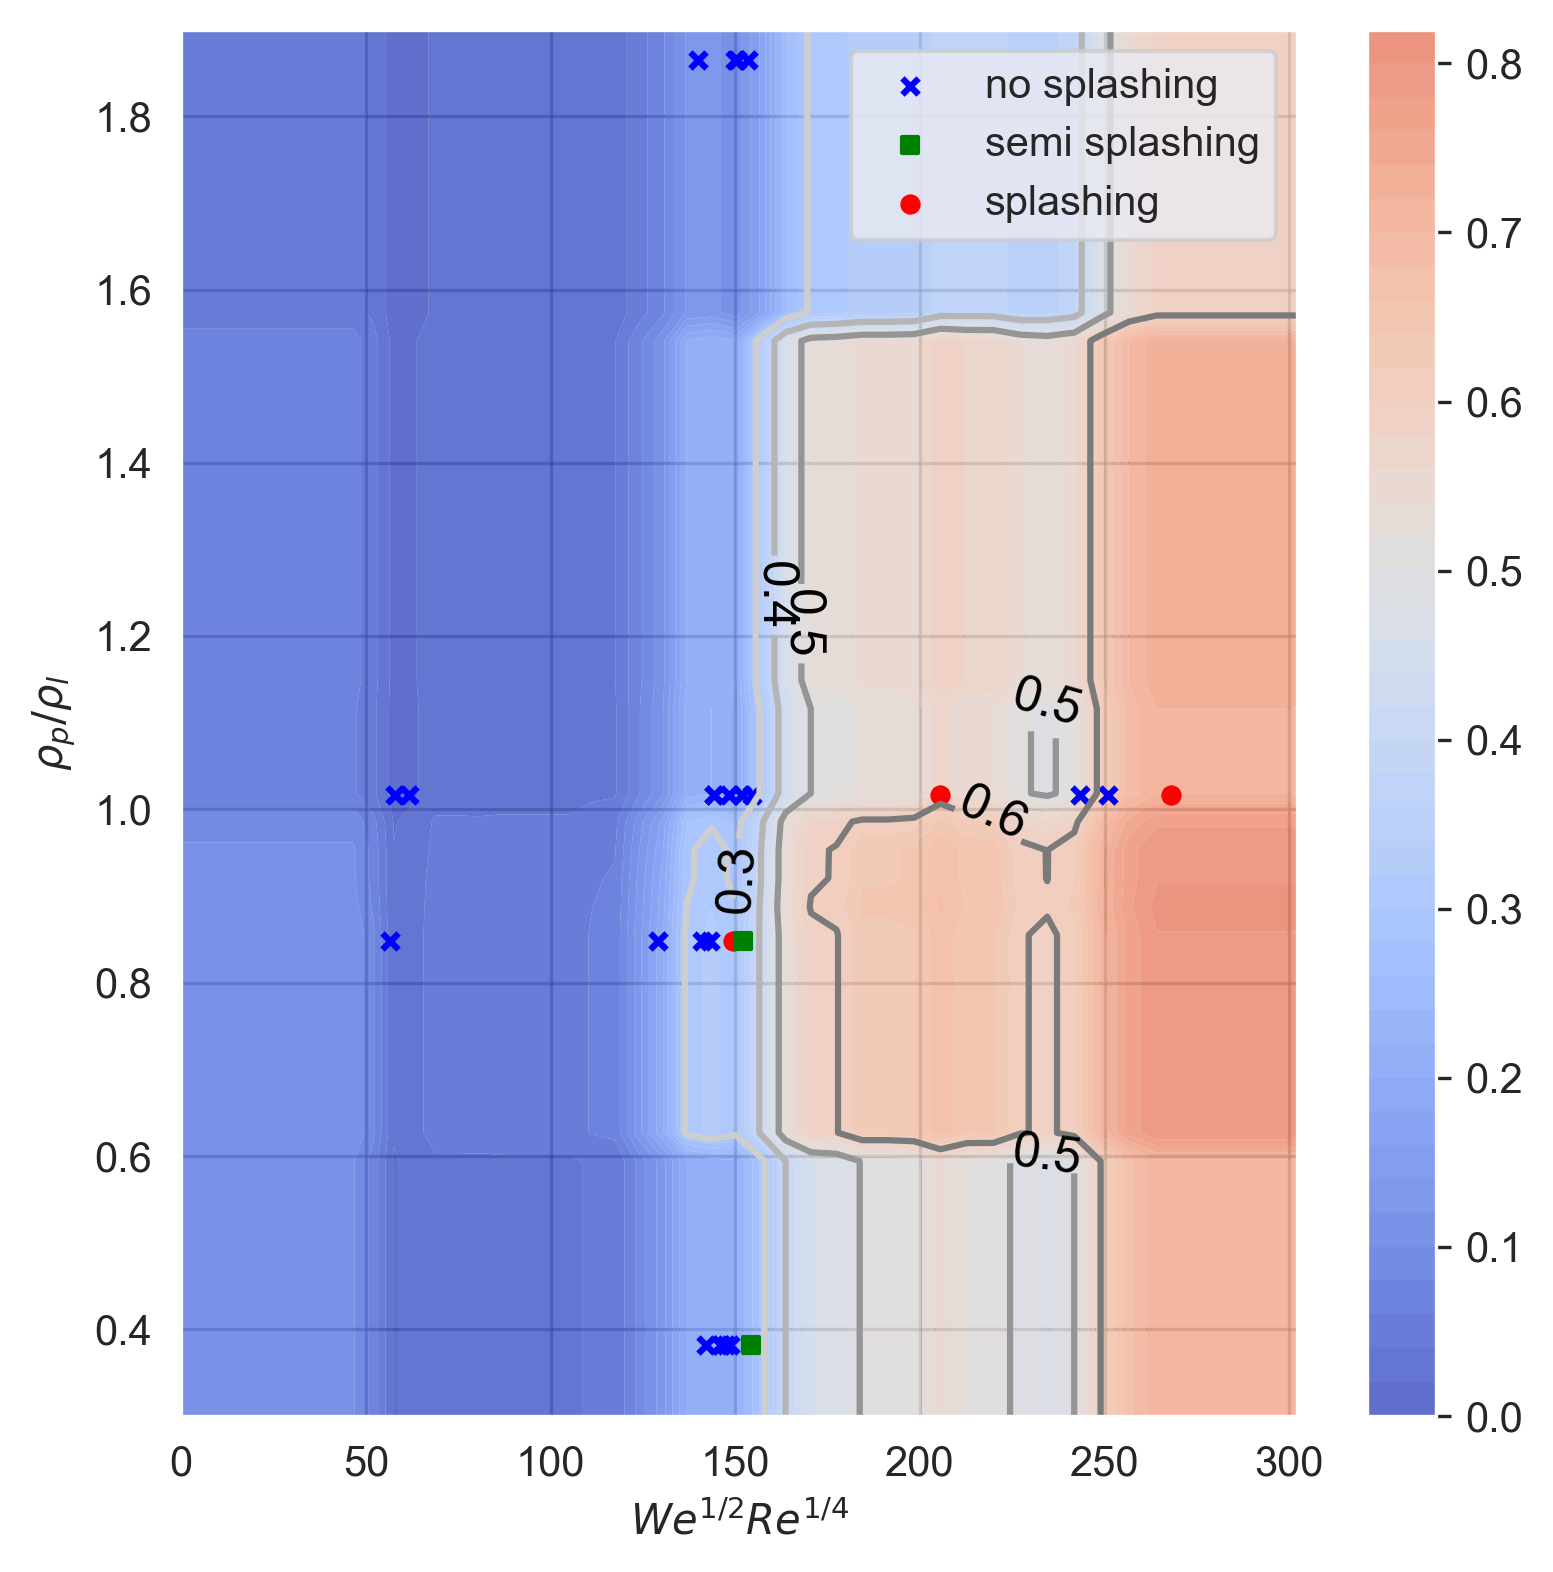

In [66]:
markersize = 15

part_diam_mask = glycerol_df['particle_mean_diameter'] ==\
    glycerol_df['particle_mean_diameter'].median()


no_splashing = glycerol_df[part_diam_mask & (glycerol_df['splashing'] == 0)]
semi_splashing = glycerol_df[part_diam_mask & (glycerol_df['splashing'] == 1)]
# splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'].isin([1,2]))]
splashing = glycerol_df[part_diam_mask & (glycerol_df['splashing'] == 2)]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

contourplot = ax.contourf(
    dens_pred_df_extr_res['We_Re'].unique(),
    dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
    dens_pred_df_extr_res['splashing'].values.reshape(50,50),
    cmap='coolwarm',
    levels=50,
    vmin=0.,
    vmax=1.,
    alpha=0.8,
    antialiased=True
)
plt.colorbar(contourplot, ax=ax)

contplot = ax.contour(
    dens_pred_df_extr_res['We_Re'].unique(),
    dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
    dens_pred_df_extr_res['splashing'].values.reshape(50,50),
    # cmap='coolwarm',
    levels=[0.3, 0.4, 0.5, 0.6],
    vmin=0.,
    vmax=1.,
    cmap='Greys',
)
ax.clabel(contplot, fmt = '%1.1f', colors = 'k', fontsize=12) #contour line labels

ax.scatter(
    x = no_splashing['We_Re'],
    y = no_splashing['particle_liquid_density_ratio'],
    marker='x',
    s=markersize,
    color='b',
    label='no splashing'
)


ax.scatter(
    x = splashing['We_Re'],
    y = splashing['particle_liquid_density_ratio'],
    marker='o',
    s=markersize,
    color='r',
    label='splashing'
)


ax.scatter(
    x = semi_splashing['We_Re'],
    y = semi_splashing['particle_liquid_density_ratio'],
    marker='s',
    s=markersize,
    color='g',
    label='semi splashing',
)

#get handles and labels
handles, labels = ax.get_legend_handles_labels()

#specify order of items in legend
order = [0, 2, 1]

#add legend to plot
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax.set_ylabel('$\\rho_{p}/\\rho_{l}$');

# ax.set_yticks(np.linspace(0.01, 0.11, 11))

ax.grid(color='black', alpha=0.5)

# plt.contour(
#     dens_pred_df_extr_res['We_Re'].unique(),
#     dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
#     dens_pred_df_extr_res['splashing'].values.reshape(50,50),
#     0.5,
# )

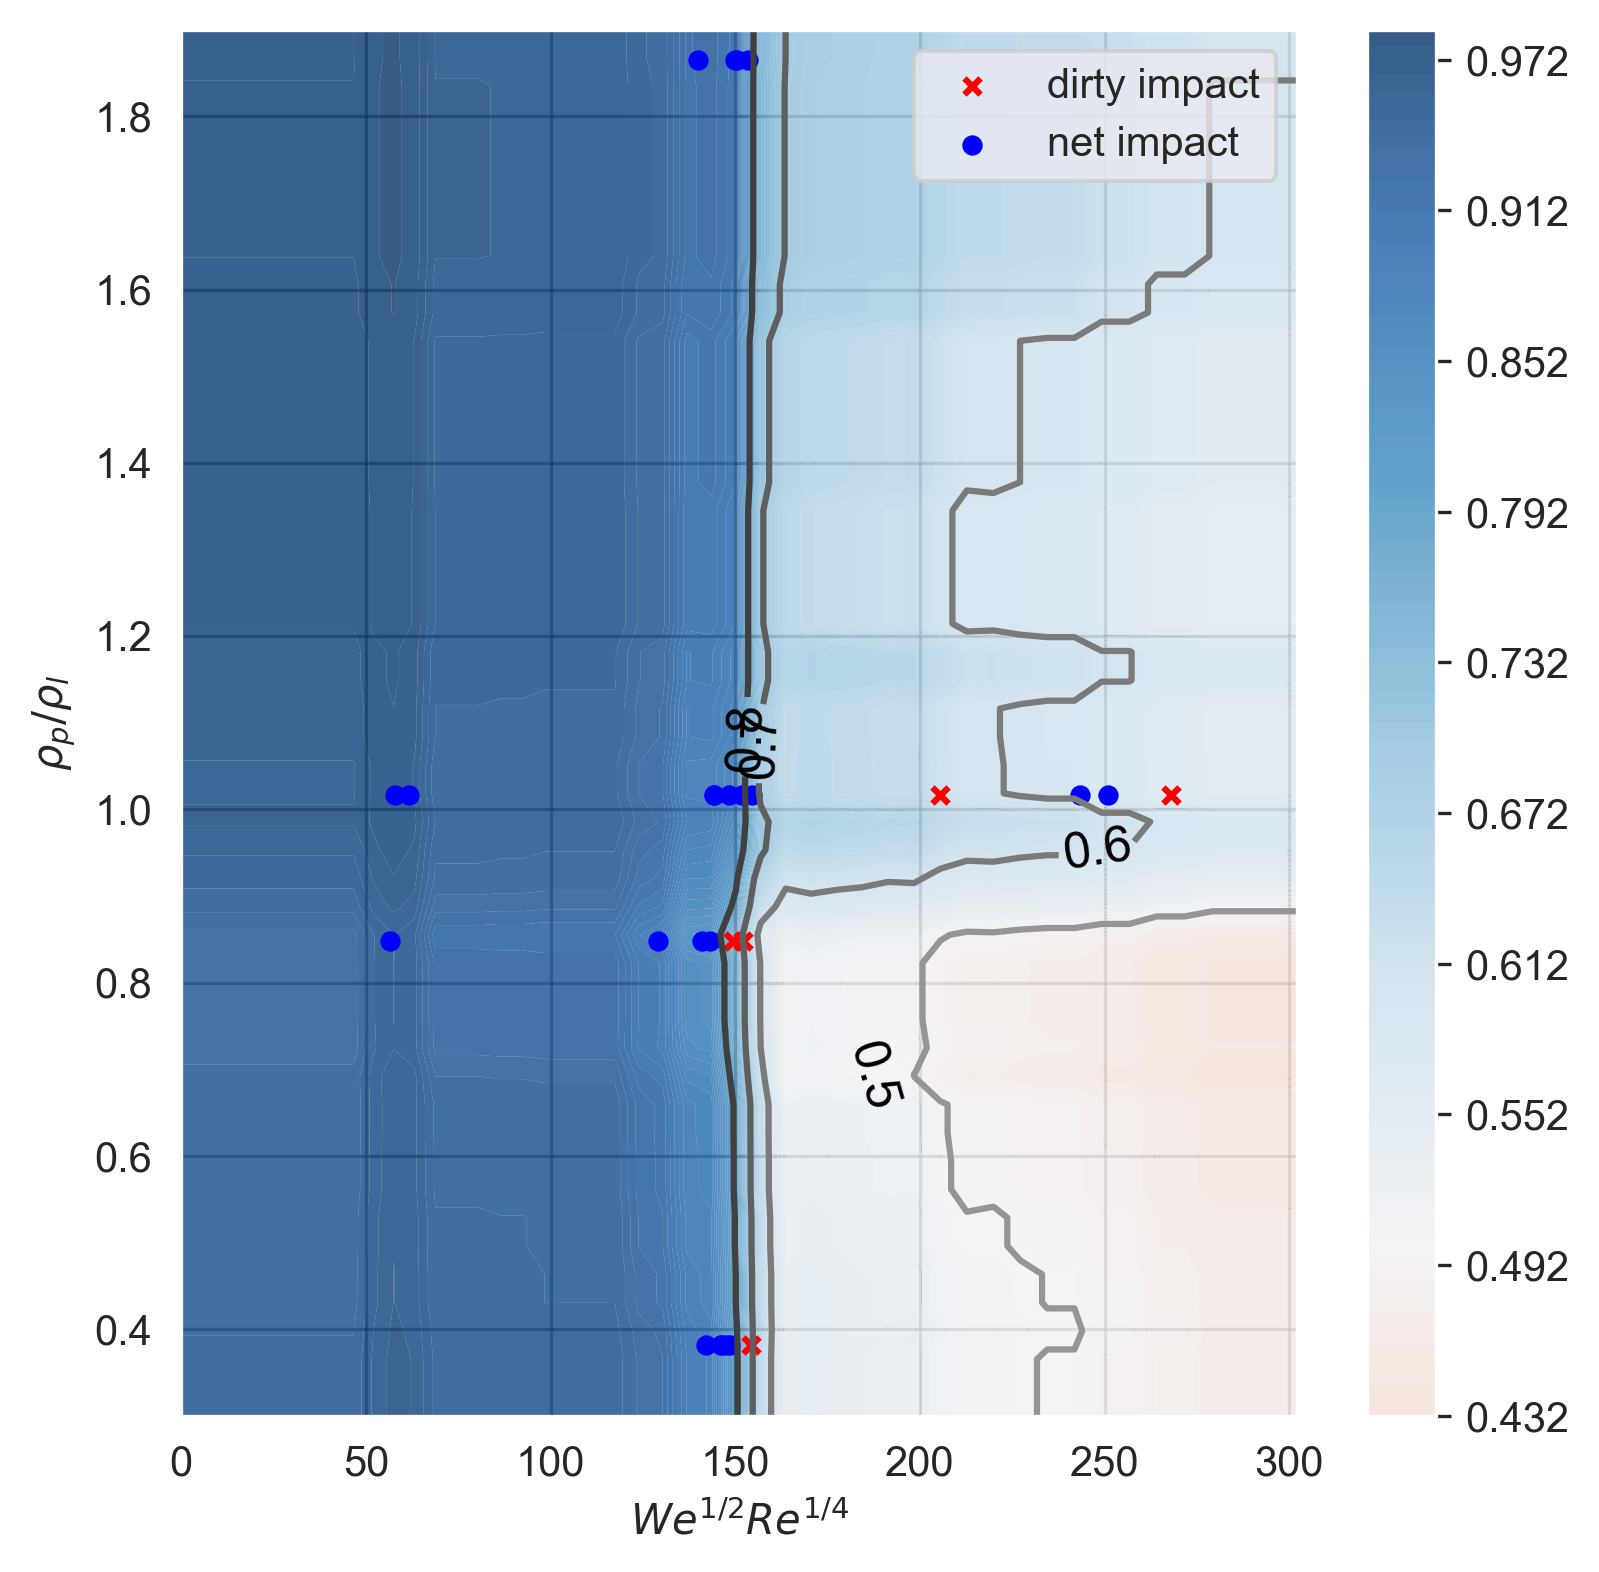

In [67]:
markersize = 15

part_diam_mask = glycerol_df['particle_mean_diameter'] ==\
    glycerol_df['particle_mean_diameter'].median()

net_impact = glycerol_df[part_diam_mask & (glycerol_df['net_impact'] == 1)]
# splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'].isin([1,2]))]
dirty_impact = glycerol_df[part_diam_mask & (glycerol_df['net_impact'] == 0)]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

contourplot = ax.contourf(
    dens_pred_df_extr_res['We_Re'].unique(),
    dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
    dens_pred_df_extr_res['net_impact'].values.reshape(50,50),
    cmap='RdBu',
    levels=100,
    vmin=0.,
    vmax=1.,
    alpha=0.8,
    antialiased=True
)
plt.colorbar(contourplot, ax=ax)

contplot = ax.contour(
    dens_pred_df_extr_res['We_Re'].unique(),
    dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
    dens_pred_df_extr_res['net_impact'].values.reshape(50,50),
    # cmap='coolwarm',
    levels=[0.5, 0.6, 0.7, 0.8],
    vmin=0.,
    vmax=1.,
    cmap='Greys',
)
ax.clabel(contplot, fmt = '%1.1f', colors = 'k', fontsize=12) #contour line labels

ax.scatter(
    x = dirty_impact['We_Re'],
    y = dirty_impact['particle_liquid_density_ratio'],
    marker='x',
    s=markersize,
    color='r',
    label='dirty impact'
)


ax.scatter(
    x = net_impact['We_Re'],
    y = net_impact['particle_liquid_density_ratio'],
    marker='o',
    s=markersize,
    color='b',
    label='net impact'
)


#get handles and labels
handles, labels = ax.get_legend_handles_labels()

#specify order of items in legend
order = [0, 1]

#add legend to plot
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax.set_ylabel('$\\rho_{p}/\\rho_{l}$');

# ax.set_yticks(np.linspace(0.01, 0.11, 11))

ax.grid(color='black', alpha=0.5)

# plt.contour(
#     dens_pred_df_extr_res['We_Re'].unique(),
#     dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
#     dens_pred_df_extr_res['splashing'].values.reshape(50,50),
#     0.5,
# )

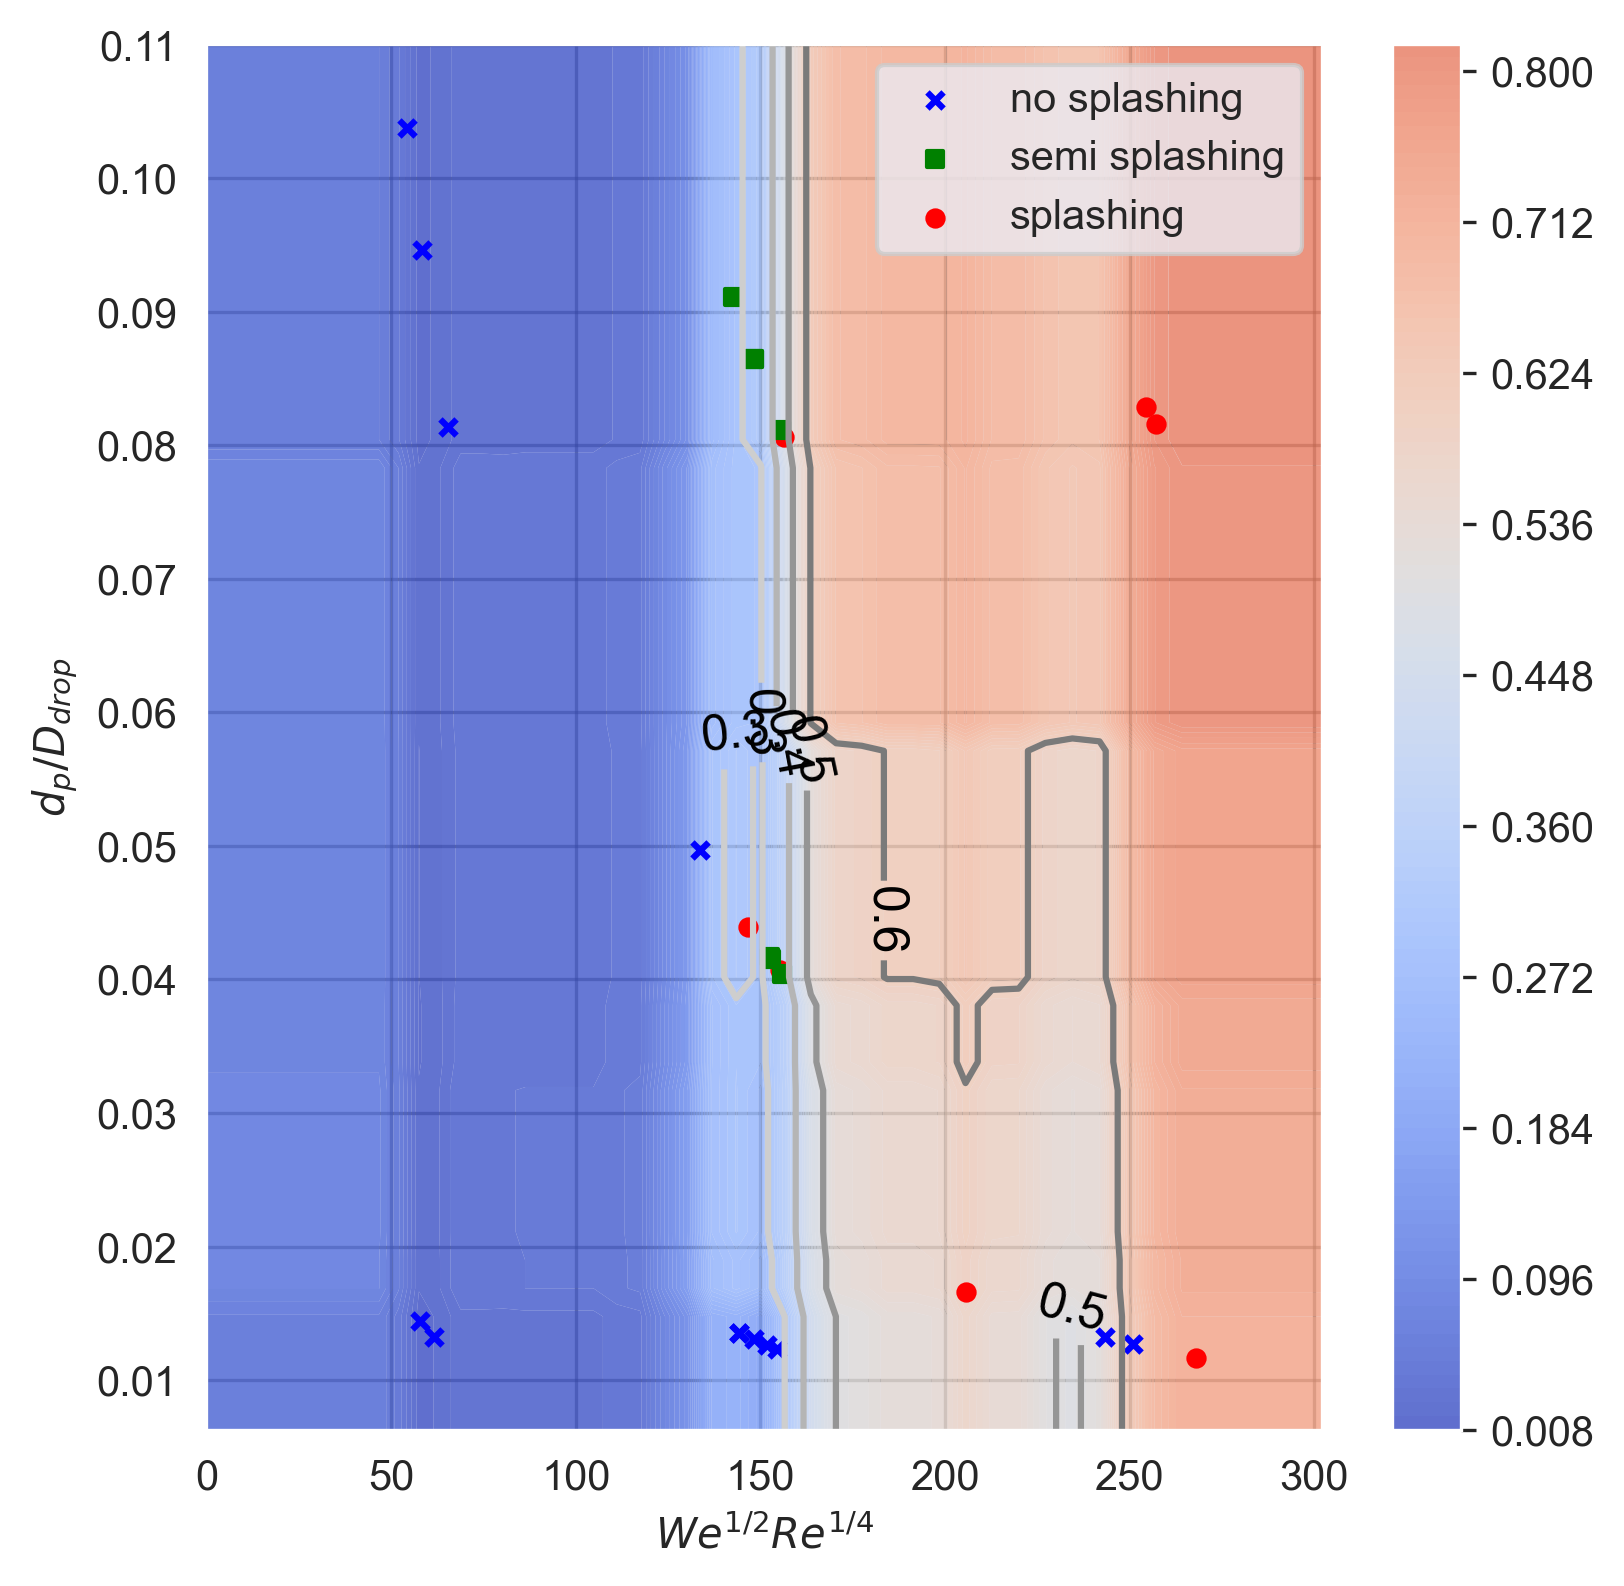

In [46]:
markersize = 15

dens_ratio_mask = glycerol_df['particle_liquid_density_ratio'] ==\
    glycerol_df['particle_liquid_density_ratio'].median()


no_splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'] == 0)]
semi_splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'] == 1)]
# splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'].isin([1,2]))]
splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'] == 2)]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

contourfplot = ax.contourf(
    diam_pred_df_extr_res['We_Re'].unique(),
    diam_pred_df_extr_res['particle_droplet_diameter_ratio'].unique(),
    diam_pred_df_extr_res['splashing'].values.reshape(50,50),
    cmap='coolwarm',
    levels=100,
    vmin=0.,
    vmax=1.,
    alpha=0.8,
    antialiased=True
)
# for c in contourfplot.collections:
#     c.set_edgecolor("face")

plt.colorbar(contourfplot, ax=ax)

contplot = ax.contour(
    diam_pred_df_extr_res['We_Re'].unique(),
    diam_pred_df_extr_res['particle_droplet_diameter_ratio'].unique(),
    diam_pred_df_extr_res['splashing'].values.reshape(50,50),
    # cmap='coolwarm',
    levels=[0.3, 0.4, 0.5, 0.6],
    vmin=0.,
    vmax=1.,
    cmap='Greys',
)
ax.clabel(contplot, fmt = '%1.1f', colors = 'k', fontsize=12); #contour line labels

ax.scatter(
    x = no_splashing['We_Re'],
    y = no_splashing['particle_droplet_diameter_ratio'],
    marker='x',
    s=markersize,
    color='b',
    label='no splashing'
)


ax.scatter(
    x = splashing['We_Re'],
    y = splashing['particle_droplet_diameter_ratio'],
    marker='o',
    s=markersize,
    color='r',
    label='splashing'
)


ax.scatter(
    x = semi_splashing['We_Re'],
    y = semi_splashing['particle_droplet_diameter_ratio'],
    marker='s',
    s=markersize,
    color='g',
    label='semi splashing',
)

# sns.scatterplot(
#     data=glycerol_df[dens_ratio_mask],
#     x='We_Re',
#     y = 'particle_droplet_diameter_ratio',
#     hue='splashing_type',
#     style='splashing_type',
#     ax=ax
# )

#get handles and labels
handles, labels = ax.get_legend_handles_labels()

#specify order of items in legend
order = [0, 2, 1]

#add legend to plot
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax.set_ylabel('$d_p/D_{drop}$');

ax.set_yticks(np.linspace(0.01, 0.11, 11))

ax.grid(color='black', alpha=0.5)

# ax_volume_fraction.set_ylabel('$\phi$')
# ax_density_ratio.set_ylabel('$\\rho_{p}/\\rho_{l}$');

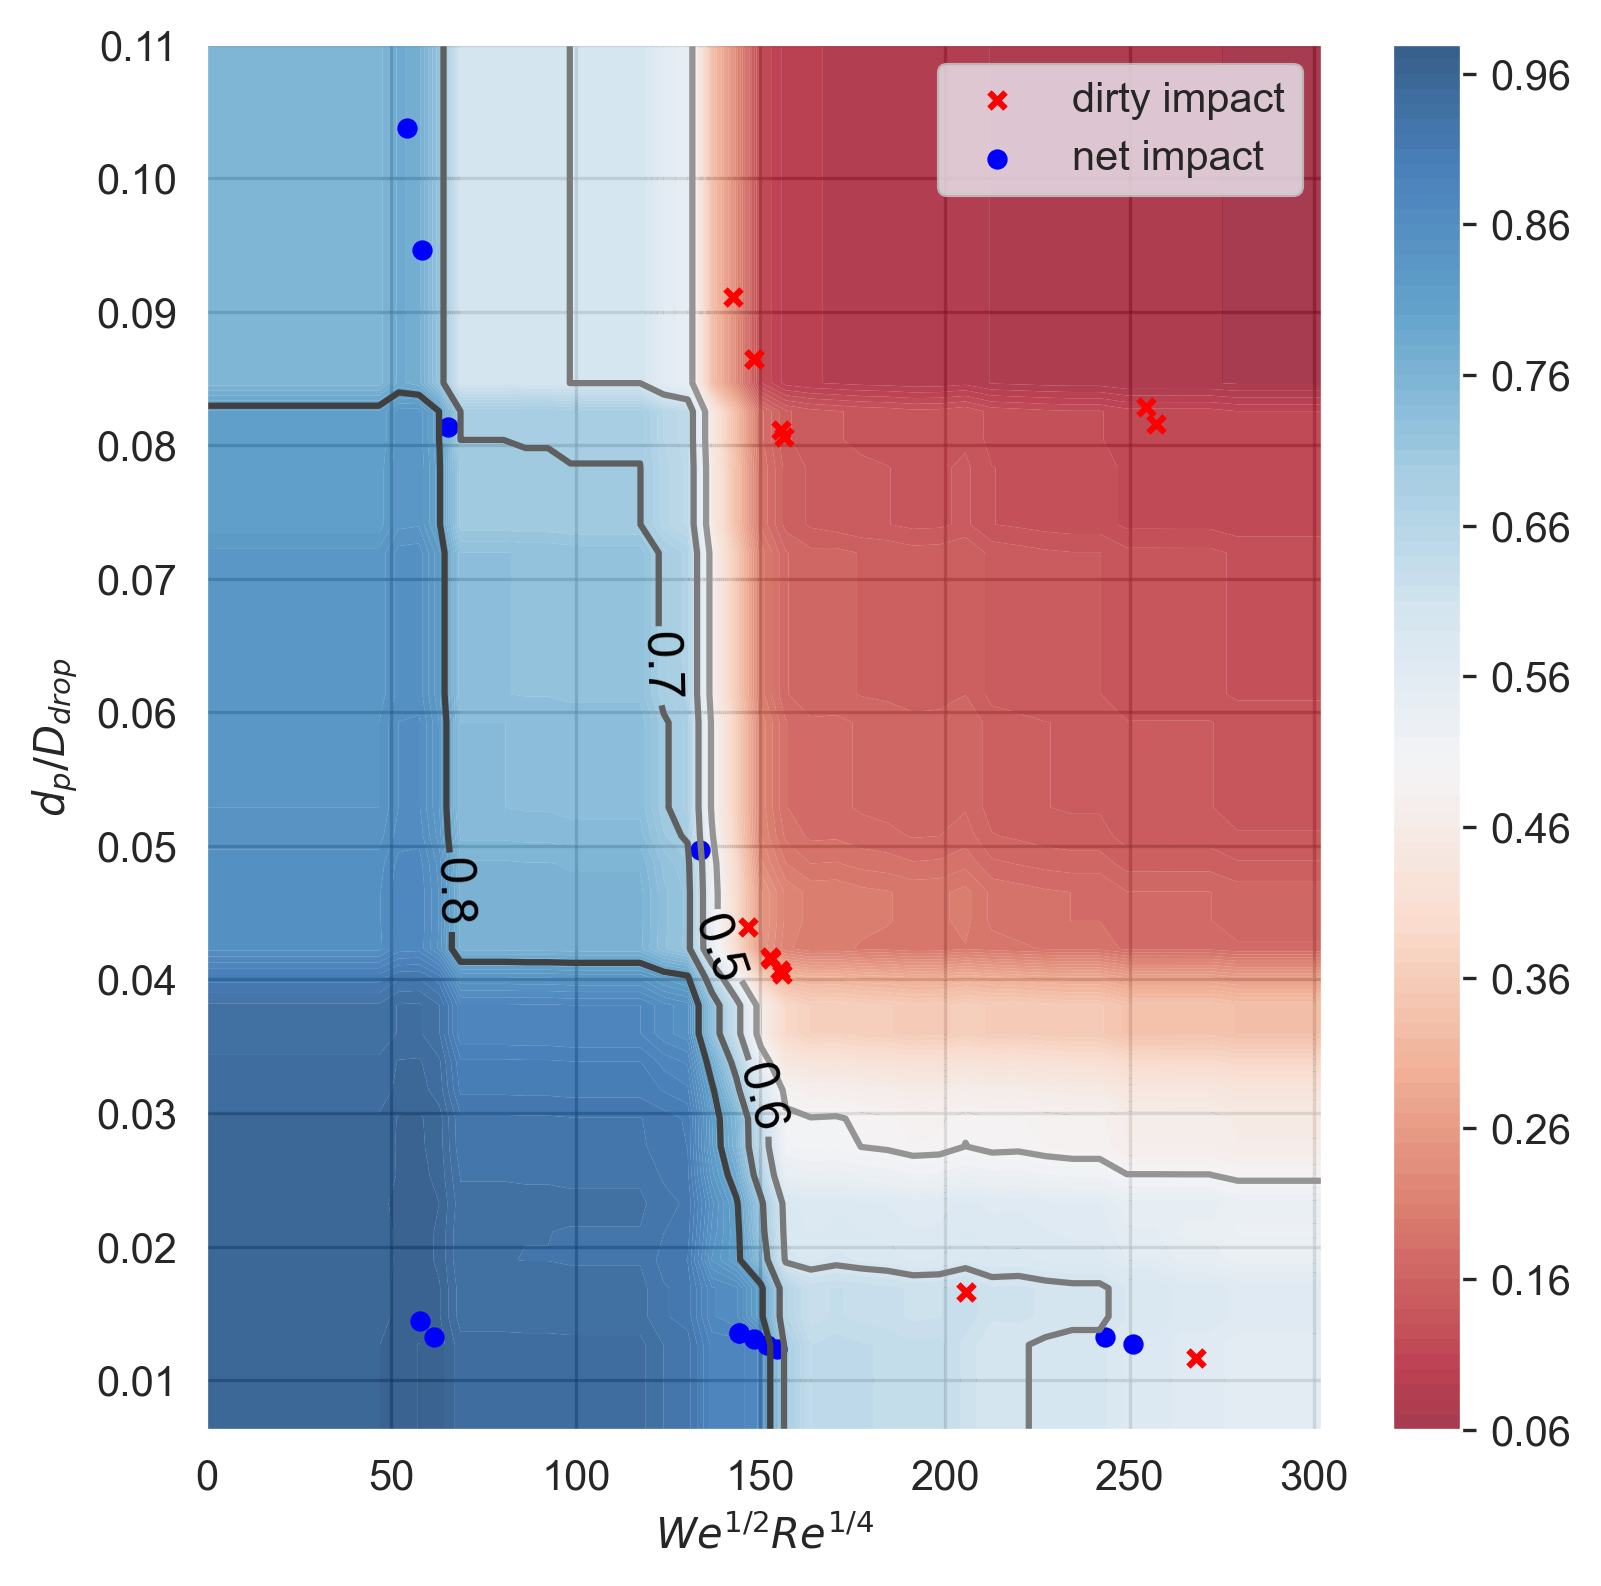

In [70]:
markersize = 15

dens_ratio_mask = glycerol_df['particle_liquid_density_ratio'] ==\
    glycerol_df['particle_liquid_density_ratio'].median()

net_impact = glycerol_df[dens_ratio_mask & (glycerol_df['net_impact'] == 1)]
# splashing = glycerol_df[dens_ratio_mask & (glycerol_df['splashing'].isin([1,2]))]
dirty_impact = glycerol_df[dens_ratio_mask & (glycerol_df['net_impact'] == 0)]

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

contourplot = ax.contourf(
    diam_pred_df_extr_res['We_Re'].unique(),
    diam_pred_df_extr_res['particle_droplet_diameter_ratio'].unique(),
    diam_pred_df_extr_res['net_impact'].values.reshape(50,50),
    cmap='RdBu',
    levels=100,
    vmin=0.,
    vmax=1.,
    alpha=0.8,
    antialiased=True
)
plt.colorbar(contourplot, ax=ax)

contplot = ax.contour(
    diam_pred_df_extr_res['We_Re'].unique(),
    diam_pred_df_extr_res['particle_droplet_diameter_ratio'].unique(),
    diam_pred_df_extr_res['net_impact'].values.reshape(50,50),
    # cmap='coolwarm',
    levels=[0.5, 0.6, 0.7, 0.8],
    vmin=0.,
    vmax=1.,
    cmap='Greys',
)
ax.clabel(contplot, fmt = '%1.1f', colors = 'k', fontsize=12) #contour line labels

ax.scatter(
    x = dirty_impact['We_Re'],
    y = dirty_impact['particle_droplet_diameter_ratio'],
    marker='x',
    s=markersize,
    color='r',
    label='dirty impact'
)


ax.scatter(
    x = net_impact['We_Re'],
    y = net_impact['particle_droplet_diameter_ratio'],
    marker='o',
    s=markersize,
    color='b',
    label='net impact'
)


#get handles and labels
handles, labels = ax.get_legend_handles_labels()

#specify order of items in legend
order = [0, 1]

#add legend to plot
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax.set_ylabel('$d_p/D_{drop}$');

ax.set_yticks(np.linspace(0.01, 0.11, 11))

ax.grid(color='black', alpha=0.5)

# plt.contour(
#     dens_pred_df_extr_res['We_Re'].unique(),
#     dens_pred_df_extr_res['particle_liquid_density_ratio'].unique(),
#     dens_pred_df_extr_res['splashing'].values.reshape(50,50),
#     0.5,
# )